Dataset Shape: (2000, 7)

Columns: ['Page Views', 'Session Duration', 'Bounce Rate', 'Traffic Source', 'Time on Page', 'Previous Visits', 'Conversion Rate']

Missing Values:
Page Views          0
Session Duration    0
Bounce Rate         0
Traffic Source      0
Time on Page        0
Previous Visits     0
Conversion Rate     0
dtype: int64

Accuracy: 0.325

Classification Report:
               precision    recall  f1-score   support

           0       0.20      0.03      0.04        40
           1       0.39      0.72      0.51       156
           2       0.19      0.17      0.18        83
           3       0.05      0.01      0.02        68
           4       0.08      0.02      0.03        53

    accuracy                           0.33       400
   macro avg       0.18      0.19      0.16       400
weighted avg       0.23      0.33      0.25       400



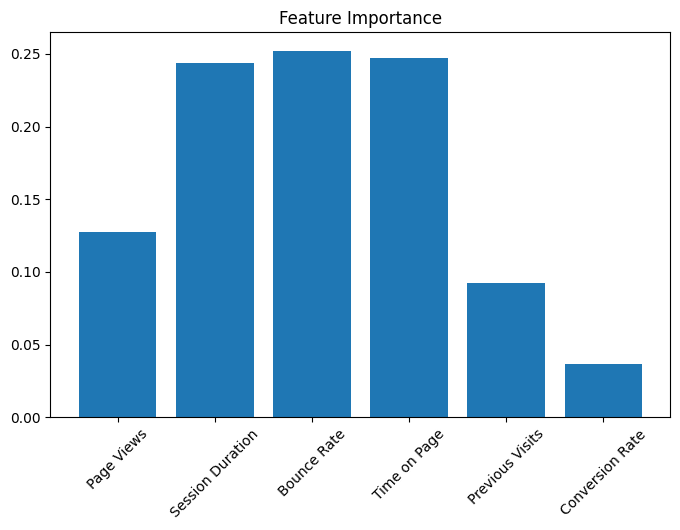

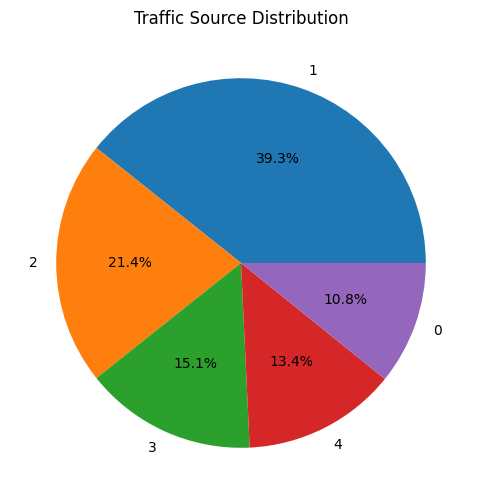

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

df = pd.read_csv("website_traffic.csv")

print("Dataset Shape:", df.shape)
print("\nColumns:", df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())

df = df.dropna()

le = LabelEncoder()
df["Traffic Source"] = le.fit_transform(df["Traffic Source"])

features = [
    "Page Views",
    "Session Duration",
    "Bounce Rate",
    "Time on Page",
    "Previous Visits",
    "Conversion Rate"
]

X = df[features]
y = df["Traffic Source"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

importance = model.feature_importances_

plt.figure(figsize=(8,5))
plt.bar(features, importance)
plt.title("Feature Importance")
plt.xticks(rotation=45)
plt.show()

traffic_counts = df["Traffic Source"].value_counts()

plt.figure(figsize=(6,6))
plt.pie(
    traffic_counts.values,
    labels=traffic_counts.index,
    autopct="%1.1f%%"
)
plt.title("Traffic Source Distribution")
plt.show()